In [7]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
import os

PROJECT_DIR = "/content/drive/MyDrive/Deepfake_Project"
RAW_DIR = os.path.join(PROJECT_DIR, "data/raw/dfdc_train_part_00")
PROCESSED_DIR = os.path.join(PROJECT_DIR, "data/processed")

CSV_DIR = os.path.join(PROCESSED_DIR, "csv")
FRAMES_DIR = os.path.join(PROCESSED_DIR, "frames")
AUDIO_DIR = os.path.join(PROCESSED_DIR, "audio")
TEXT_DIR = os.path.join(PROCESSED_DIR, "text")

OUTPUT_DIR = os.path.join(PROJECT_DIR, "data/outputs")
MODEL_DIR = os.path.join(OUTPUT_DIR, "models")
GRAPH_DIR = os.path.join(OUTPUT_DIR, "graphs")
REPORT_DIR = os.path.join(OUTPUT_DIR, "reports")
PRED_DIR = os.path.join(OUTPUT_DIR, "predictions")
EXPLAIN_DIR = os.path.join(OUTPUT_DIR, "explainability")
UNCERTAIN_DIR = os.path.join(OUTPUT_DIR, "uncertain_samples")

for folder in [CSV_DIR, FRAMES_DIR, AUDIO_DIR, TEXT_DIR, MODEL_DIR, GRAPH_DIR, REPORT_DIR, PRED_DIR, EXPLAIN_DIR, UNCERTAIN_DIR]:
    os.makedirs(folder, exist_ok=True)

print("All folders are ready.")

All folders are ready.


In [9]:
import os
import json
import pandas as pd

metadata_path = os.path.join(RAW_DIR, "metadata.json")

with open(metadata_path, "r") as f:
    metadata = json.load(f)

df = pd.DataFrame.from_dict(metadata, orient="index")
df.reset_index(inplace=True)
df.rename(columns={"index": "filename"}, inplace=True)

df["video_path"] = df["filename"].apply(lambda x: os.path.join(RAW_DIR, x))

print(df.head())
print(df.columns)
print(df["label"].value_counts())

         filename label  split        original  \
0  owxbbpjpch.mp4  FAKE  train  wynotylpnm.mp4   
1  vpmyeepbep.mp4  REAL  train             NaN   
2  fzvpbrzssi.mp4  REAL  train             NaN   
3  htorvhbcae.mp4  FAKE  train  wclvkepakb.mp4   
4  fckxaqjbxk.mp4  FAKE  train  vpmyeepbep.mp4   

                                          video_path  
0  /content/drive/MyDrive/Deepfake_Project/data/r...  
1  /content/drive/MyDrive/Deepfake_Project/data/r...  
2  /content/drive/MyDrive/Deepfake_Project/data/r...  
3  /content/drive/MyDrive/Deepfake_Project/data/r...  
4  /content/drive/MyDrive/Deepfake_Project/data/r...  
Index(['filename', 'label', 'split', 'original', 'video_path'], dtype='object')
label
FAKE    1248
REAL      86
Name: count, dtype: int64


In [10]:
metadata_csv = os.path.join(CSV_DIR, "metadata_part00.csv")
df.to_csv(metadata_csv, index=False)
print("Saved:", metadata_csv)

Saved: /content/drive/MyDrive/Deepfake_Project/data/processed/csv/metadata_part00.csv


In [11]:
real_df = df[df["label"] == "REAL"].sample(80, random_state=42)
fake_df = df[df["label"] == "FAKE"].sample(80, random_state=42)

sample_df = pd.concat([real_df, fake_df]).sample(frac=1, random_state=42).reset_index(drop=True)

sample_csv = os.path.join(CSV_DIR, "sample_160_videos.csv")
sample_df.to_csv(sample_csv, index=False)

print(sample_df["label"].value_counts())
print("Total videos:", len(sample_df))
print("Saved:", sample_csv)
print(sample_df.head())

label
FAKE    80
REAL    80
Name: count, dtype: int64
Total videos: 160
Saved: /content/drive/MyDrive/Deepfake_Project/data/processed/csv/sample_160_videos.csv
         filename label  split        original  \
0  kxhwssipyi.mp4  FAKE  train  sttnfyptum.mp4   
1  ratscdfvdk.mp4  FAKE  train  ddtbarpcgo.mp4   
2  lxnqzocgaq.mp4  FAKE  train  xjzkfqddyk.mp4   
3  xchzardbfa.mp4  REAL  train             NaN   
4  iocjgjemeb.mp4  FAKE  train  sttnfyptum.mp4   

                                          video_path  
0  /content/drive/MyDrive/Deepfake_Project/data/r...  
1  /content/drive/MyDrive/Deepfake_Project/data/r...  
2  /content/drive/MyDrive/Deepfake_Project/data/r...  
3  /content/drive/MyDrive/Deepfake_Project/data/r...  
4  /content/drive/MyDrive/Deepfake_Project/data/r...  


In [12]:
import cv2
from tqdm import tqdm

def extract_frames(video_path, save_dir, num_frames=5):
    cap = cv2.VideoCapture(video_path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if total_frames <= 0:
        cap.release()
        return 0

    frame_indices = [int(i * total_frames / num_frames) for i in range(num_frames)]

    saved = 0
    current_idx = 0

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        if current_idx in frame_indices:
            frame_name = f"frame_{current_idx}.jpg"
            cv2.imwrite(os.path.join(save_dir, frame_name), frame)
            saved += 1

        current_idx += 1

    cap.release()
    return saved

In [13]:
frame_records = []

for _, row in tqdm(sample_df.iterrows(), total=len(sample_df)):
    filename = row["filename"]
    label = row["label"]
    video_path = row["video_path"]

    video_id = os.path.splitext(filename)[0]

    save_dir = os.path.join(FRAMES_DIR, label, video_id)
    os.makedirs(save_dir, exist_ok=True)

    count = extract_frames(video_path, save_dir, num_frames=5)

    frame_records.append({
        "filename": filename,
        "label": label,
        "frames_saved": count
    })

frames_df = pd.DataFrame(frame_records)

print(frames_df.head())
print(frames_df["frames_saved"].value_counts())

100%|██████████| 160/160 [12:12<00:00,  4.58s/it]

         filename label  frames_saved
0  kxhwssipyi.mp4  FAKE             5
1  ratscdfvdk.mp4  FAKE             5
2  lxnqzocgaq.mp4  FAKE             5
3  xchzardbfa.mp4  REAL             5
4  iocjgjemeb.mp4  FAKE             5
frames_saved
5    160
Name: count, dtype: int64


In [14]:
image_rows = []

for _, row in sample_df.iterrows():
    filename = row["filename"]
    label = row["label"]

    video_id = os.path.splitext(filename)[0]
    frame_dir = os.path.join(FRAMES_DIR, label, video_id)

    if os.path.exists(frame_dir):
        for img in os.listdir(frame_dir):
            if img.endswith(".jpg"):
                image_rows.append({
                    "image_path": os.path.join(frame_dir, img),
                    "label": label
                })

image_df = pd.DataFrame(image_rows)

print(image_df.head())
print(image_df["label"].value_counts())
print("Total images:", len(image_df))

                                          image_path label
0  /content/drive/MyDrive/Deepfake_Project/data/p...  FAKE
1  /content/drive/MyDrive/Deepfake_Project/data/p...  FAKE
2  /content/drive/MyDrive/Deepfake_Project/data/p...  FAKE
3  /content/drive/MyDrive/Deepfake_Project/data/p...  FAKE
4  /content/drive/MyDrive/Deepfake_Project/data/p...  FAKE
label
FAKE    1200
REAL    1200
Name: count, dtype: int64
Total images: 2400


In [15]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    image_df,
    test_size=0.2,
    stratify=image_df["label"],
    random_state=42
)

print("Train:", train_df["label"].value_counts())
print("Validation:", val_df["label"].value_counts())

Train: label
REAL    960
FAKE    960
Name: count, dtype: int64
Validation: label
REAL    240
FAKE    240
Name: count, dtype: int64


In [16]:
print(image_df["label"].value_counts())
print("Total images:", len(image_df))

label
FAKE    1200
REAL    1200
Name: count, dtype: int64
Total images: 2400


In [17]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = 224
BATCH_SIZE = 16

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_dataframe(
    train_df,
    x_col="image_path",
    y_col="label",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary"
)

val_gen = val_datagen.flow_from_dataframe(
    val_df,
    x_col="image_path",
    y_col="label",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

print(train_gen.class_indices)

Found 1920 validated image filenames belonging to 2 classes.
Found 480 validated image filenames belonging to 2 classes.
{'FAKE': 0, 'REAL': 1}


In [18]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model

base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
x = Dense(128, activation="relu")(x)
x = Dropout(0.3)(x)

output = Dense(1, activation="sigmoid")(x)

visual_model = Model(inputs=base_model.input, outputs=output)

visual_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

visual_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
history = visual_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=15
)

Epoch 1/15
120/120 ━━━━━━━━━━━━━━━━━━━━ 142s 1s/step - accuracy: 0.5490 - loss: 0.7422 - val_accuracy: 0.6854 - val_loss: 0.6077
Epoch 2/15
120/120 ━━━━━━━━━━━━━━━━━━━━ 136s 1s/step - accuracy: 0.6339 - loss: 0.6744 - val_accuracy: 0.6521 - val_loss: 0.6040
Epoch 3/15
120/120 ━━━━━━━━━━━━━━━━━━━━ 126s 1s/step - accuracy: 0.6526 - loss: 0.6436 - val_accuracy: 0.6938 - val_loss: 0.5917
Epoch 4/15
120/120 ━━━━━━━━━━━━━━━━━━━━ 126s 1s/step - accuracy: 0.6448 - loss: 0.6398 - val_accuracy: 0.7083 - val_loss: 0.5890
Epoch 5/15
120/120 ━━━━━━━━━━━━━━━━━━━━ 152s 1s/step - accuracy: 0.6526 - loss: 0.6263 - val_accuracy: 0.6792 - val_loss: 0.5910
Epoch 6/15
120/120 ━━━━━━━━━━━━━━━━━━━━ 130s 1s/step - accuracy: 0.6734 - loss: 0.6140 - val_accuracy: 0.7146 - val_loss: 0.5838
Epoch 7/15
120/120 ━━━━━━━━━━━━━━━━━━━━ 126s 1s/step - accuracy: 0.6724 - loss: 0.6139 - val_accuracy: 0.7188 - val_loss: 0.5799
Epoch 8/15
120/120 ━━━━━━━━━━━━━━━━━━━━ 128s 1s/step - accuracy: 0.6708 - loss: 0.6205 - val_accu

In [ ]:
visual_model_path = os.path.join(MODEL_DIR, "visual_mobilenetv2_model.keras")
visual_model.save(visual_model_path)

print("Saved:", visual_model_path)

Saved: /content/drive/MyDrive/Deepfake_Project/data/outputs/models/visual_mobilenetv2_model.keras


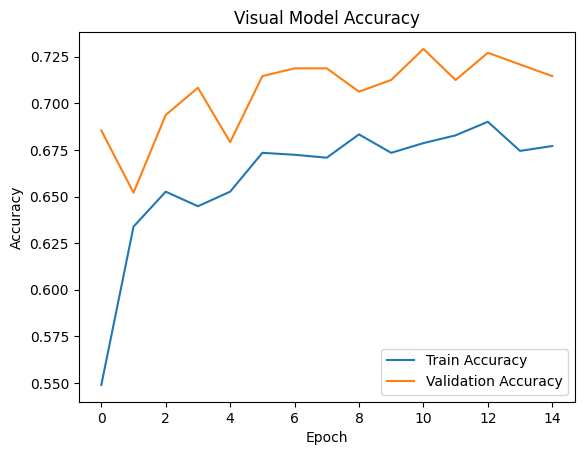

Saved: /content/drive/MyDrive/Deepfake_Project/data/outputs/graphs/visual_accuracy_graph.png


In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Visual Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

graph_path = os.path.join(GRAPH_DIR, "visual_accuracy_graph.png")
plt.savefig(graph_path)
plt.show()

print("Saved:", graph_path)

In [ ]:
!pip install -q moviepy librosa soundfile openai-whisper

In [ ]:
from moviepy.editor import VideoFileClip
from tqdm import tqdm

audio_records = []

for _, row in tqdm(sample_df.iterrows(), total=len(sample_df)):
    filename = row["filename"]
    label = row["label"]
    video_path = row["video_path"]

    out_dir = os.path.join(AUDIO_DIR, label)
    os.makedirs(out_dir, exist_ok=True)

    audio_path = os.path.join(out_dir, os.path.splitext(filename)[0] + ".wav")

    status = "not_extracted"

    try:
        if os.path.exists(audio_path):
            status = "already_exists"
        else:
            clip = VideoFileClip(video_path)
            if clip.audio is not None:
                clip.audio.write_audiofile(audio_path, logger=None)
                status = "extracted"
            else:
                status = "no_audio"
            clip.close()
    except Exception as e:
        status = "error"

    audio_records.append({
        "filename": filename,
        "label": label,
        "audio_path": audio_path,
        "audio_status": status
    })

audio_df = pd.DataFrame(audio_records)
audio_csv = os.path.join(CSV_DIR, "audio_extraction_summary.csv")
audio_df.to_csv(audio_csv, index=False)

print(audio_df["audio_status"].value_counts())
print("Saved:", audio_csv)

100%|██████████| 160/160 [00:00<00:00, 576.60it/s]


audio_status
already_exists    160
Name: count, dtype: int64
Saved: /content/drive/MyDrive/Deepfake_Project/data/processed/csv/audio_extraction_summary.csv


In [ ]:
import whisper

whisper_model = whisper.load_model("base")

In [ ]:
text_rows = []

for _, row in tqdm(audio_df.iterrows(), total=len(audio_df)):
    filename = row["filename"]
    label = row["label"]
    audio_path = row["audio_path"]

    transcript = ""

    if os.path.exists(audio_path):
        try:
            result = whisper_model.transcribe(audio_path)
            transcript = result["text"]
        except Exception as e:
            transcript = ""

    text_rows.append({
        "filename": filename,
        "label": label,
        "audio_path": audio_path,
        "transcript": transcript
    })

text_df = pd.DataFrame(text_rows)

text_csv = os.path.join(TEXT_DIR, "text_features_whisper.csv")
text_df.to_csv(text_csv, index=False)

print(text_df.head())
print("Saved:", text_csv)

  0%|          | 0/160 [00:00<?, ?it/s]WARNING:py.warnings:/usr/local/lib/python3.12/dist-packages/whisper/transcribe.py:132: UserWarning: FP16 is not supported on CPU; using FP32 instead
  warnings.warn("FP16 is not supported on CPU; using FP32 instead")

  1%|          | 1/160 [00:08<21:51,  8.25s/it]WARNING:py.warnings:/usr/local/lib/python3.12/dist-packages/whisper/transcribe.py:132: UserWarning: FP16 is not supported on CPU; using FP32 instead
  warnings.warn("FP16 is not supported on CPU; using FP32 instead")

  1%|▏         | 2/160 [00:12<16:05,  6.11s/it]WARNING:py.warnings:/usr/local/lib/python3.12/dist-packages/whisper/transcribe.py:132: UserWarning: FP16 is not supported on CPU; using FP32 instead
  warnings.warn("FP16 is not supported on CPU; using FP32 instead")

  2%|▏         | 3/160 [00:17<14:27,  5.52s/it]WARNING:py.warnings:/usr/local/lib/python3.12/dist-packages/whisper/transcribe.py:132: UserWarning: FP16 is not supported on CPU; using FP32 instead
  warnings.warn("

         filename label                                         audio_path  \
0  kxhwssipyi.mp4  FAKE  /content/drive/MyDrive/Deepfake_Project/data/p...   
1  ratscdfvdk.mp4  FAKE  /content/drive/MyDrive/Deepfake_Project/data/p...   
2  lxnqzocgaq.mp4  FAKE  /content/drive/MyDrive/Deepfake_Project/data/p...   
3  xchzardbfa.mp4  REAL  /content/drive/MyDrive/Deepfake_Project/data/p...   
4  iocjgjemeb.mp4  FAKE  /content/drive/MyDrive/Deepfake_Project/data/p...   

                                          transcript  
0   less than a little bit harder than other peop...  
1   I don't even know what half of them are anymo...  
2   Why do we need art? Well, we need art for so ...  
3   R.I. has changed in a lot of ways with techno...  
4   less than a little bit harder than other peop...  
Saved: /content/drive/MyDrive/Deepfake_Project/data/processed/text/text_features_whisper.csv


In [ ]:
print(text_df["transcript"].head(10))
print("Empty transcripts:", (text_df["transcript"].str.strip() == "").sum())

0     less than a little bit harder than other peop...
1     I don't even know what half of them are anymo...
2     Why do we need art? Well, we need art for so ...
3     R.I. has changed in a lot of ways with techno...
4     less than a little bit harder than other peop...
5     So it makes us think like, okay, these are, I...
6     make something beautiful through those aforem...
7     It's real. This is this like life of luxury T...
8     your family or your loved ones that had turne...
9     and ships had been dumping them. Merchantship...
Name: transcript, dtype: object
Empty transcripts: 0


In [ ]:
import librosa
import numpy as np

def extract_mfcc(audio_path):
    try:
        y, sr = librosa.load(audio_path, sr=16000)
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
        return np.mean(mfcc, axis=1)
    except:
        return np.zeros(13)

In [ ]:
audio_feature_rows = []

for _, row in tqdm(audio_df.iterrows(), total=len(audio_df)):
    features = extract_mfcc(row["audio_path"])

    record = {
        "filename": row["filename"],
        "label": row["label"],
        "audio_path": row["audio_path"]
    }

    for i, value in enumerate(features):
        record[f"mfcc_{i+1}"] = value

    audio_feature_rows.append(record)

audio_features_df = pd.DataFrame(audio_feature_rows)

audio_features_csv = os.path.join(CSV_DIR, "audio_features_mfcc.csv")
audio_features_df.to_csv(audio_features_csv, index=False)

print(audio_features_df.head())
print("Saved:", audio_features_csv)

100%|██████████| 160/160 [00:14<00:00, 11.14it/s]

         filename label                                         audio_path  \
0  kxhwssipyi.mp4  FAKE  /content/drive/MyDrive/Deepfake_Project/data/p...   
1  ratscdfvdk.mp4  FAKE  /content/drive/MyDrive/Deepfake_Project/data/p...   
2  lxnqzocgaq.mp4  FAKE  /content/drive/MyDrive/Deepfake_Project/data/p...   
3  xchzardbfa.mp4  REAL  /content/drive/MyDrive/Deepfake_Project/data/p...   
4  iocjgjemeb.mp4  FAKE  /content/drive/MyDrive/Deepfake_Project/data/p...   

       mfcc_1     mfcc_2     mfcc_3     mfcc_4     mfcc_5     mfcc_6  \
0 -410.739136  96.866005  -7.448000  17.368610 -10.510450 -14.920521   
1 -463.254791  91.861320  -4.841594  15.173532 -13.326157  -2.756058   
2 -477.235809  93.086708  34.393505  34.861996   9.857111   0.469813   
3 -459.674835  99.065712  21.345387  23.941250  -6.497448   8.534845   
4 -410.739136  96.866005  -7.448000  17.368610 -10.510450 -14.920521   

      mfcc_7    mfcc_8     mfcc_9    mfcc_10    mfcc_11   mfcc_12   mfcc_13  
0 -15.605047 -4.7297

In [ ]:
print(audio_df["audio_status"].value_counts())

audio_status
already_exists    160
Name: count, dtype: int64


In [ ]:
from transformers import pipeline

# Use a pretrained BERT model for sentence similarity check
similarity_model = pipeline('zero-shot-classification')

def check_semantic_consistency(text, video_context):
    # Use BERT to check if the speech text is relevant to the video context
    result = similarity_model(text, candidate_labels=[video_context])
    return result['labels'][0], result['scores'][0]  # Return the most likely label and score

# Example
text = "This is a deepfake video"
video_context = "Deepfake detection"
label, score = check_semantic_consistency(text, video_context)
print(f"Semantic Consistency: {label} with score {score}")

No model was supplied, defaulted to facebook/bart-large-mnli and revision d7645e1.
Using a pipeline without specifying a model name and revision in production is not recommended.
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(



Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

Semantic Consistency: Deepfake detection with score 0.6431253552436829


### 1. Generating Text Embeddings

We will use a pre-trained Sentence Transformer model to convert the text transcripts into numerical embeddings. These embeddings capture the semantic meaning of the text, which can then be used as features for our multimodal model.

In [ ]:
import os
import pandas as pd
import numpy as np
from sentence_transformers import SentenceTransformer
from sklearn.preprocessing import StandardScaler

# Load the text_df (if not already in memory)
text_csv_path = os.path.join(TEXT_DIR, "text_features_whisper.csv")
text_df = pd.read_csv(text_csv_path)

# Initialize a pre-trained sentence transformer model
embedding_model = SentenceTransformer('all-MiniLM-L6-v2')

# Generate embeddings for transcripts
def get_text_embeddings(transcripts):
    return embedding_model.encode(transcripts.tolist(), show_progress_bar=True)

# Handle potential empty transcripts by filling them with a space
text_df['transcript'] = text_df['transcript'].fillna(" ")
text_embeddings = get_text_embeddings(text_df['transcript'])

# Create a DataFrame for text embeddings
text_embeddings_df = pd.DataFrame(text_embeddings)
text_embeddings_df.columns = [f"text_emb_{i+1}" for i in range(text_embeddings.shape[1])]
text_embeddings_df["filename"] = text_df["filename"]
text_embeddings_df["label"] = text_df["label"]

print("Text embeddings generated successfully:")
print(text_embeddings_df.head())

# Save text embeddings to CSV
text_embeddings_csv = os.path.join(CSV_DIR, "text_embeddings.csv")
text_embeddings_df.to_csv(text_embeddings_csv, index=False)
print("Saved:", text_embeddings_csv)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/5 [00:00<?, ?it/s]

Text embeddings generated successfully:
   text_emb_1  text_emb_2  text_emb_3  text_emb_4  text_emb_5  text_emb_6  \
0    0.107053   -0.083120    0.007272   -0.005697   -0.034123   -0.052899   
1    0.013844   -0.114022    0.071411   -0.003065    0.029122   -0.029518   
2   -0.001048    0.035484    0.056384   -0.037367    0.062205    0.060869   
3   -0.090705    0.005998    0.031994   -0.005298    0.067380    0.003482   
4    0.107053   -0.083120    0.007272   -0.005697   -0.034123   -0.052899   

   text_emb_7  text_emb_8  text_emb_9  text_emb_10  ...  text_emb_377  \
0   -0.017827    0.116791   -0.004680     0.056711  ...      0.000744   
1    0.004116   -0.004472    0.039393    -0.029416  ...     -0.006439   
2    0.046498   -0.085342    0.090442    -0.053290  ...      0.008189   
3    0.099271    0.013728    0.004775     0.017969  ...     -0.010979   
4   -0.017827    0.116791   -0.004680     0.056711  ...      0.000744   

   text_emb_378  text_emb_379  text_emb_380  text_emb_381 

### 2. Extracting Visual Features from Pre-trained Model

Instead of raw pixels, we'll use the learned features from an intermediate layer of our trained `visual_model`. Specifically, we'll extract the output of the `GlobalAveragePooling2D` layer, which represents a high-level visual summary for each image. We'll then average these features for all frames belonging to the same video to get a video-level visual feature vector.

In [ ]:
from tensorflow.keras.models import Model

# Create a feature extraction model from the trained visual_model
# We'll take the output of the GlobalAveragePooling2D layer as our feature vector
feature_extractor = Model(inputs=visual_model.input, outputs=visual_model.get_layer('global_average_pooling2d').output)

visual_features_records = []

# Group image_df by video filename to process frames per video
# Re-load sample_df to get original filenames for mapping
image_df_with_video_id = image_df.copy()
image_df_with_video_id['video_filename'] = image_df_with_video_id['image_path'].apply(lambda x: os.path.basename(os.path.dirname(x)) + '.mp4' if os.path.basename(os.path.dirname(x)) != 'REAL' and os.path.basename(os.path.dirname(x)) != 'FAKE' else os.path.basename(os.path.dirname(os.path.dirname(x))) + '.mp4')

for video_filename, group_df in tqdm(image_df_with_video_id.groupby('video_filename'), total=len(image_df_with_video_id['video_filename'].unique())):
    image_paths = group_df['image_path'].tolist()
    video_label = group_df['label'].iloc[0]

    # Load and preprocess images
    images = []
    for img_path in image_paths:
        img = tf.keras.utils.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
        img_array = tf.keras.utils.img_to_array(img)
        img_array = np.expand_dims(img_array, axis=0) # Add batch dimension
        img_array = img_array / 255.0 # Rescale as done in ImageDataGenerator
        images.append(img_array)

    if images:
        images = np.vstack(images)
        # Extract features
        features = feature_extractor.predict(images, verbose=0)
        # Average features across frames for the video
        avg_features = np.mean(features, axis=0)

        record = {"filename": video_filename, "label": video_label}
        for i, val in enumerate(avg_features):
            record[f"visual_feat_{i+1}"] = val
        visual_features_records.append(record)

visual_features_df = pd.DataFrame(visual_features_records)

# Save visual features
visual_features_csv = os.path.join(CSV_DIR, "visual_features.csv")
visual_features_df.to_csv(visual_features_csv, index=False)

print("Visual features extracted and saved successfully:")
print(visual_features_df.head())
print(f"Shape of visual features: {visual_features_df.shape}")

100%|██████████| 160/160 [02:33<00:00,  1.04it/s]


Visual features extracted and saved successfully:
         filename label  visual_feat_1  visual_feat_2  visual_feat_3  \
0  aayrffkzxn.mp4  REAL       0.003722       0.002344       0.030530   
1  acdkfksyev.mp4  FAKE       0.000000       0.000000       0.092555   
2  achdeirhym.mp4  FAKE       0.006926       0.000000       0.133472   
3  alnkzqihau.mp4  FAKE       0.008657       0.014857       0.087755   
4  apedduehoy.mp4  REAL       0.000589       0.000019       0.136945   

   visual_feat_4  visual_feat_5  visual_feat_6  visual_feat_7  visual_feat_8  \
0       2.779534       0.701063       0.462731       0.093197       0.471233   
1       0.535834       0.016100       1.702423       0.133387       0.000251   
2       0.644294       0.017976       1.912634       0.054007       0.000613   
3       2.295890       0.873869       0.724338       0.192705       0.240896   
4       1.545488       0.125872       1.282985       0.445268       0.110163   

   ...  visual_feat_1271  visual_fea

### 3. Combining All Features (Visual, Audio, Text)

Now we will merge the extracted visual features, MFCC audio features, and text embeddings into a single DataFrame based on the `filename`. This combined DataFrame will serve as the input for our multimodal classifier.

In [ ]:
# Ensure all dataframes are ready
# audio_features_df is already loaded in qdN2sPeOyyta
# text_embeddings_df created above
# visual_features_df created above

# Merge visual and audio features
combined_features_df = pd.merge(
    visual_features_df,
    audio_features_df.drop(columns=["label", "audio_path"]), # Drop label and path to avoid duplication
    on="filename",
    how="inner"
)

# Merge with text embeddings
combined_features_df = pd.merge(
    combined_features_df,
    text_embeddings_df.drop(columns=["label"]), # Drop label to avoid duplication
    on="filename",
    how="inner"
)

# Verify the merged dataframe
print("Combined features head:")
print(combined_features_df.head())
print(f"Combined features shape: {combined_features_df.shape}")

# Save combined features
combined_features_csv = os.path.join(CSV_DIR, "multimodal_features.csv")
combined_features_df.to_csv(combined_features_csv, index=False)
print("Saved combined multimodal features to:", combined_features_csv)

Combined features head:
         filename label  visual_feat_1  visual_feat_2  visual_feat_3  \
0  aayrffkzxn.mp4  REAL       0.003722       0.002344       0.030530   
1  acdkfksyev.mp4  FAKE       0.000000       0.000000       0.092555   
2  achdeirhym.mp4  FAKE       0.006926       0.000000       0.133472   
3  alnkzqihau.mp4  FAKE       0.008657       0.014857       0.087755   
4  apedduehoy.mp4  REAL       0.000589       0.000019       0.136945   

   visual_feat_4  visual_feat_5  visual_feat_6  visual_feat_7  visual_feat_8  \
0       2.779534       0.701063       0.462731       0.093197       0.471233   
1       0.535834       0.016100       1.702423       0.133387       0.000251   
2       0.644294       0.017976       1.912634       0.054007       0.000613   
3       2.295890       0.873869       0.724338       0.192705       0.240896   
4       1.545488       0.125872       1.282985       0.445268       0.110163   

   ...  text_emb_375  text_emb_376  text_emb_377  text_emb_378

### 7. Alternative Multimodal Classifier: 1D Convolutional Neural Network (CNN)

Instead of a traditional machine learning model like Logistic Regression or SVM, we can use a 1D Convolutional Neural Network (CNN) to learn hierarchical patterns within the concatenated feature vector. This can potentially capture more complex interactions between the visual, audio, and text features.

First, we'll need to reshape our scaled feature data (`X_train_scaled` and `X_test_scaled`) to add a 'channel' dimension, which is typically required for `Conv1D` layers (e.g., `(samples, timesteps, features)`). In our case, `timesteps` will be the number of features, and `features` will be 1.

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, GlobalAveragePooling1D, Dense, Dropout
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Reshape data for Conv1D input (samples, timesteps, features)
# Here, each feature is a 'timestep' and there's 1 'feature' channel
X_train_reshaped = X_train_scaled.reshape(X_train_scaled.shape[0], X_train_scaled.shape[1], 1)
X_test_reshaped = X_test_scaled.reshape(X_test_scaled.shape[0], X_test_scaled.shape[1], 1)

# Define the 1D CNN model
cnn_multimodal_model = Sequential([
    Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(X_train_reshaped.shape[1], 1)),
    MaxPooling1D(pool_size=2),
    Conv1D(filters=128, kernel_size=3, activation='relu'),
    GlobalAveragePooling1D(), # or Flatten() followed by Dense layers
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid') # Binary classification
])

# Compile the model
cnn_multimodal_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

cnn_multimodal_model.summary()

  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 1675, 64)       │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 837, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 835, 128)       │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,281 (130.00 KB)

 Trainable params: 33,281 (130.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_cnn = cnn_multimodal_model.fit(
    X_train_reshaped,
    y_train,
    epochs=20, # You might want to adjust the number of epochs
    batch_size=16,
    validation_data=(X_test_reshaped, y_test),
    verbose=1
)

NameError: name 'y_train' is not defined

Finally, we'll evaluate the performance of our 1D CNN model using accuracy, classification report, and a confusion matrix, similar to our previous models.

In [ ]:
def get_predicted_label_with_uncertainty(prob_real, original_pred_label_int):
    if 0.4 < prob_real < 0.6:
        return "Uncertain"
    elif original_pred_label_int == 1:
        return "REAL"
    else:
        return "FAKE"

def classify_risk(prob_real):
    if 0.4 <= prob_real <= 0.6:
        return "Medium Risk"
    elif prob_real < 0.4: # Low probability of being REAL means high probability of being FAKE
        return "High Risk"
    else: # High probability of being REAL means low risk of being FAKE
        return "Low Risk"


In [ ]:
# Make predictions with the CNN model
y_prob_cnn = cnn_multimodal_model.predict(X_test_reshaped).flatten()
y_pred_cnn = (y_prob_cnn > 0.5).astype(int)

# Evaluate the CNN model
print("\nMultimodal 1D CNN Model Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_cnn):.4f}")
print("\nClassification Report (1D CNN):")
print(classification_report(y_test, y_pred_cnn))

# Confusion Matrix for CNN
cm_cnn = confusion_matrix(y_test, y_pred_cnn)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_cnn, annot=True, fmt="d", cmap="Blues",
            xticklabels=['FAKE', 'REAL'],
            yticklabels=['FAKE', 'REAL'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Multimodal 1D CNN Model Confusion Matrix")
plt.show()

# Prepare test results for CNN with uncertainty and risk classification
predicted_labels_with_uncertainty_cnn = [
    get_predicted_label_with_uncertainty(prob, pred)
    for prob, pred in zip(y_prob_cnn, y_pred_cnn)
]

test_results_cnn = pd.DataFrame({
    "filename": combined_features_df.loc[X_test.index, 'filename'].values,
    "true_label": y_test.map({0: "FAKE", 1: "REAL"}).values,
    "predicted_label": predicted_labels_with_uncertainty_cnn,
    "predicted_probability_REAL": y_prob_cnn
})

test_results_cnn["risk_level"] = test_results_cnn["predicted_probability_REAL"].apply(classify_risk)

print("\n1D CNN Test Results with Risk Level (first 10 samples):")
display(test_results_cnn.head(10))

print("\n1D CNN Predicted Label Counts:")
display(test_results_cnn['predicted_label'].value_counts())

### 5. Alternative Multimodal Classifiers: SVM and CNN

While Logistic Regression is a good baseline, other models can be used:

*   **Support Vector Machines (SVMs)**: Effective for high-dimensional data, SVMs aim to find the optimal hyperplane that best separates classes. They can handle non-linear relationships using different kernel functions.
*   **Convolutional Neural Networks (CNNs) for Fusion**: For a more advanced approach, you could design a custom CNN architecture that takes the concatenated feature vectors (visual, audio, text) as input. This network would learn complex interactions between modalities and perform the final classification. This typically involves more intricate model design and training.

Below, we'll demonstrate using an SVM as an alternative to Logistic Regression for multimodal classification.

In [ ]:
import os
import shap
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split # Explicitly import
from sklearn.preprocessing import StandardScaler # Explicitly import
import pandas as pd # Explicitly import

# Ensure global path variables are defined
PROJECT_DIR = "/content/drive/MyDrive/Deepfake_Project"
PROCESSED_DIR = os.path.join(PROJECT_DIR, "data/processed")
CSV_DIR = os.path.join(PROCESSED_DIR, "csv")

def get_predicted_label_with_uncertainty(prob_real, original_pred_label_int):
    if 0.4 < prob_real < 0.6:
        return "Uncertain"
    elif original_pred_label_int == 1:
        return "REAL"
    else:
        return "FAKE"

def classify_risk(prob_real):
    if 0.4 <= prob_real <= 0.6:
        return "Medium Risk"
    elif prob_real < 0.4: # Low probability of being REAL means high probability of being FAKE
        return "High Risk"
    else: # High probability of being REAL means low risk of being FAKE
        return "Low Risk"

# Ensure X_train_scaled, X_test_scaled, y_train are defined
# (These should be defined by the execution of d31232ce)
if 'X_train_scaled' not in locals() or 'X_test_scaled' not in locals():
    # Re-run necessary setup if previous cells were skipped
    if 'combined_features_df' not in locals():
        combined_features_csv = os.path.join(CSV_DIR, "multimodal_features.csv")
        combined_features_df = pd.read_csv(combined_features_csv)
    # Define X and y within this block if not already defined globally or from d31232ce
    X = combined_features_df.drop(columns=["filename", "label"])
    y = combined_features_df["label"].map({"FAKE": 0, "REAL": 1})
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

# Train an SVM model
multimodal_svm_model = SVC(kernel='rbf', probability=True, random_state=42)
multimodal_svm_model.fit(X_train_scaled, y_train)

# Make predictions with SVM
y_pred_svm = multimodal_svm_model.predict(X_test_scaled)
y_prob_svm = multimodal_svm_model.predict_proba(X_test_scaled)[:, 1] # Probability of being REAL

# Evaluate the SVM model
print("\nMultimodal SVM Model Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_svm):.4f}")
print("\nClassification Report (SVM):")
print(classification_report(y_test, y_pred_svm))

# Confusion Matrix for SVM
cm_svm = confusion_matrix(y_test, y_pred_svm)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_svm, annot=True, fmt="d", cmap="Blues",
            xticklabels=['FAKE', 'REAL'],
            yticklabels=['FAKE', 'REAL'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Multimodal SVM Model Confusion Matrix")
plt.show()

# Update the multimodal_model to SVM for subsequent analysis
multimodal_model = multimodal_svm_model

# Re-initialize explainer and feature_names for the new model
# feature_names were derived from X.columns earlier
# Ensure X is defined before accessing X.columns
if 'X' not in locals(): # This check handles scenarios where d31232ce didn't run or define X
    if 'combined_features_df' not in locals():
        combined_features_csv = os.path.join(CSV_DIR, "multimodal_features.csv")
        combined_features_df = pd.read_csv(combined_features_csv)
    X = combined_features_df.drop(columns=["filename", "label"])

feature_names = X.columns.tolist()
# KernelExplainer needs a background dataset, using X_train_scaled as before
# Ensure shap is imported
if 'shap' not in globals():
    import shap
explainer = shap.KernelExplainer(multimodal_model.predict_proba, X_train_scaled)
shap_values = explainer.shap_values(X_test_scaled)


# Prepare test results for SVM
predicted_labels_with_uncertainty_svm = [
    get_predicted_label_with_uncertainty(prob, pred)
    for prob, pred in zip(y_prob_svm, y_pred_svm)
]

test_results_svm = pd.DataFrame({
    "filename": combined_features_df.loc[X_test.index, 'filename'].values,
    "true_label": y_test.map({0: "FAKE", 1: "REAL"}).values,
    "predicted_label": predicted_labels_with_uncertainty_svm,
    "predicted_probability_REAL": y_prob_svm
})

test_results_svm["risk_level"] = test_results_svm["predicted_probability_REAL"].apply(classify_risk)

print("\nSVM Test Results with Risk Level (first 10 samples):")
display(test_results_svm.head(10))

print("SVM Predicted Label Counts:")
display(test_results_svm['predicted_label'].value_counts())

In [ ]:
# This cell is now merged with cell 8d1fedd1 and will remain empty.

#### 6.3 Visual Evidence with Grad-CAM on a Specific Frame

As discussed, Grad-CAM is suitable for CNNs. We can apply it to our `visual_model` to highlight regions in a specific image frame that contributed to its classification. This helps understand the visual evidence the model focused on.

Below, we'll select one of the frames from the `selected_filename` video and apply Grad-CAM.

In [ ]:
import os
import numpy as np
import tensorflow as tf
import cv2
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import Model
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
import pandas as pd # Added for test_results fallback
from sklearn.model_selection import train_test_split # Added for test_results fallback
from sklearn.linear_model import LogisticRegression # Added for test_results fallback
from sklearn.preprocessing import StandardScaler # Added for test_results fallback
import matplotlib.pyplot as plt

# Ensure global path variables are defined
PROJECT_DIR = "/content/drive/MyDrive/Deepfake_Project"
PROCESSED_DIR = os.path.join(PROJECT_DIR, "data/processed")
CSV_DIR = os.path.join(PROCESSED_DIR, "csv")
GRAPH_DIR = os.path.join(PROJECT_DIR, "data/outputs/graphs")
FRAMES_DIR = os.path.join(PROCESSED_DIR, "frames")

# Define IMG_SIZE
IMG_SIZE = 224

# Assuming visual_model are defined in earlier cells
# Assuming feature_extractor is also defined earlier (e.g., in deef2c6c)

def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    # Create a model that maps the input image to the activations of the last conv layer as well as the output predictions
    grad_model = Model(
        inputs=[model.inputs],
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )

    # Compute the gradient of the top predicted class for our input image with respect to the activations of the last conv layer
    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    # This is the gradient of the output neuron (top predicted or chosen) with respect to the output feature map of the last convolutional layer
    grads = tape.gradient(class_channel, last_conv_layer_output)

    # This is a vector where each entry is the mean intensity of the gradient over a specific feature map channel
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # Multiply each channel in the feature map array by "how important this channel is" with regard to the top predicted class
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # For visualization purpose, normalize the heatmap between 0 & 1
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

def display_gradcam(img_path, heatmap, alpha=0.4):
    # Load the original image
    img = cv2.imread(img_path)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))

    # Convert heatmap to RGB and blend with original image
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    superimposed_img = heatmap * alpha + img
    superimposed_img = np.clip(superimposed_img, 0, 255).astype(np.uint8)

    # Display the image
    plt.imshow(cv2.cvtColor(superimposed_img, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()

def get_predicted_label_with_uncertainty(prob_real, original_pred_label_int):
    if 0.4 < prob_real < 0.6:
        return "Uncertain"
    elif original_pred_label_int == 1:
        return "REAL"
    else:
        return "FAKE"

# --- Apply Grad-CAM to a frame from the selected video ---

# Ensure test_results is defined (from cell 2b08c334)
if 'test_results' not in locals():
    # This block is a fallback and assumes d31232ce and 2b08c334 would have run
    # Ideally, execution order should ensure 'test_results' exists
    if 'combined_features_df' not in locals():
        combined_features_csv = os.path.join(CSV_DIR, "multimodal_features.csv")
        combined_features_df = pd.read_csv(combined_features_csv)
    X = combined_features_df.drop(columns=["filename", "label"])
    y = combined_features_df["label"].map({"FAKE": 0, "REAL": 1})
    _, X_test, _, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    scaler = StandardScaler()
    # Assume X_train_scaled was fit previously, or re-fit if necessary
    # If this cell runs completely independently, X_train needs to be generated.
    # For robustness, we'll assume X is available from combined_features_df if it's the first time running
    X_train_fallback, X_test_fallback, y_train_fallback, y_test_fallback = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    X_train_scaled = scaler.fit_transform(X_train_fallback) # Use fallback train data to fit scaler
    X_test_scaled = scaler.transform(X_test_fallback) # Scale fallback test data

    multimodal_model = LogisticRegression(max_iter=1000, random_state=42)
    multimodal_model.fit(X_train_scaled, y_train_fallback) # Fit model with fallback train data
    y_pred = multimodal_model.predict(X_test_scaled)
    y_prob = multimodal_model.predict_proba(X_test_scaled)[:, 1]
    predicted_labels_with_uncertainty = [
        get_predicted_label_with_uncertainty(prob, pred)
        for prob, pred in zip(y_prob, y_pred)
    ]
    test_results = pd.DataFrame({
        "filename": combined_features_df.loc[X_test.index, 'filename'].values,
        "true_label": y_test.map({0: "FAKE", 1: "REAL"}).values,
        "predicted_label": predicted_labels_with_uncertainty,
        "predicted_probability_REAL": y_prob
    })

# Select a filename from the test results for demonstration
if not test_results.empty:
    selected_filename = test_results['filename'].iloc[0] # Pick the first one for demonstration
else:
    selected_filename = None
    print("No test results available to select a filename for Grad-CAM.")

if selected_filename:
    # Get the directory of frames for the selected video
    video_label = test_results.loc[test_results['filename'] == selected_filename, 'true_label'].iloc[0]
    video_id = os.path.splitext(selected_filename)[0]
    frame_dir_for_video = os.path.join(FRAMES_DIR, video_label, video_id)

    # Check if the directory exists and has frames
    if os.path.exists(frame_dir_for_video) and os.listdir(frame_dir_for_video):
        # Select one frame (e.g., the first one found)
        first_frame_name = os.listdir(frame_dir_for_video)[0]
        frame_path = os.path.join(frame_dir_for_video, first_frame_name)

        print(f"\nApplying Grad-CAM to frame: {frame_path}")

        # Preprocess the image for the visual model
        img = image.load_img(frame_path, target_size=(IMG_SIZE, IMG_SIZE))
        img_array = image.img_to_array(img)
        img_array = np.expand_dims(img_array, axis=0)
        img_array = preprocess_input(img_array) # MobileNetV2 specific preprocessing

        # Define the last convolutional layer name for MobileNetV2
        last_conv_layer_name = "block_13_expand"

        # Generate heatmap
        # Assuming visual_model is available globally
        heatmap = make_gradcam_heatmap(img_array, visual_model, last_conv_layer_name)

        # Display Grad-CAM result
        print(f"Grad-CAM for a frame from '{selected_filename}' (Visual Model Prediction):")
        display_gradcam(frame_path, heatmap)

        # Save the Grad-CAM image (optional)
        gradcam_img_path = os.path.join(GRAPH_DIR, f"gradcam_{video_id}_{first_frame_name}")
        img_to_save = cv2.imread(frame_path)
        img_to_save = cv2.resize(img_to_save, (IMG_SIZE, IMG_SIZE))
        heatmap_resized = cv2.resize(heatmap, (img_to_save.shape[1], img_to_save.shape[0]))
        heatmap_rgb = np.uint8(255 * heatmap_resized)
        heatmap_rgb = cv2.applyColorMap(heatmap_rgb, cv2.COLORMAP_JET)
        superimposed_img_save = heatmap_rgb * 0.4 + img_to_save
        superimposed_img_save = np.clip(superimposed_img_save, 0, 255).astype(np.uint8)
        cv2.imwrite(gradcam_img_path, superimposed_img_save)
        print("Saved Grad-CAM image to:", gradcam_img_path)

    else:
        print(f"No frames found for video: {selected_filename} in {frame_dir_for_video}")
else:
    print("Cannot perform Grad-CAM: selected_filename is not defined.")

### 4. Training a Multimodal Classifier

Finally, we will use the combined feature vectors to train a new classifier. For demonstration, we'll use a Logistic Regression model, but more complex models like a Feed-Forward Neural Network could also be used. We'll split the data into training and testing sets, train the model, and evaluate its performance.

In [ ]:
import os
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd # Ensure pandas is imported

# Ensure global path variables are defined
PROJECT_DIR = "/content/drive/MyDrive/Deepfake_Project"
PROCESSED_DIR = os.path.join(PROJECT_DIR, "data/processed")
CSV_DIR = os.path.join(PROCESSED_DIR, "csv")

# Ensure combined_features_df is loaded if not already in memory
if 'combined_features_df' not in locals():
    combined_features_csv = os.path.join(CSV_DIR, "multimodal_features.csv")
    combined_features_df = pd.read_csv(combined_features_csv)

# Prepare data for training
X = combined_features_df.drop(columns=["filename", "label"])
y = combined_features_df["label"].map({"FAKE": 0, "REAL": 1})

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features (important for many models like Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train a Logistic Regression model
multimodal_model = LogisticRegression(max_iter=1000, random_state=42)
multimodal_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred = multimodal_model.predict(X_test_scaled)
y_prob = multimodal_model.predict_proba(X_test_scaled)[:, 1] # Probability of being REAL

# Evaluate the model
print("Multimodal Model Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=multimodal_model.classes_,
            yticklabels=multimodal_model.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Multimodal Model Confusion Matrix")
plt.show()

In [ ]:
import os
import pandas as pd # Ensure pandas is imported
from sklearn.model_selection import train_test_split # Ensure train_test_split is imported

# Ensure global path variables are defined
PROJECT_DIR = "/content/drive/MyDrive/Deepfake_Project"
PROCESSED_DIR = os.path.join(PROJECT_DIR, "data/processed")
CSV_DIR = os.path.join(PROCESSED_DIR, "csv")

def get_predicted_label_with_uncertainty(prob_real, original_pred_label_int):
    if 0.4 < prob_real < 0.6:
        return "Uncertain"
    elif original_pred_label_int == 1:
        return "REAL"
    else:
        return "FAKE"

# Ensure combined_features_df is loaded if not already in memory
if 'combined_features_df' not in locals():
    combined_features_csv = os.path.join(CSV_DIR, "multimodal_features.csv")
    combined_features_df = pd.read_csv(combined_features_csv)

# Ensure X_test and y_test are defined from the previous cell
if 'X_test' not in locals():
    # This part should ideally be covered by running the previous cell (d31232ce)
    # but for robustness, we re-initialize if needed.
    X = combined_features_df.drop(columns=["filename", "label"])
    y = combined_features_df["label"].map({"FAKE": 0, "REAL": 1})
    # NOTE: To recreate X_test, we need X, y, and train_test_split.
    # We also need to be careful with random_state to ensure consistency with d31232ce
    _, X_test, _, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

predicted_labels_with_uncertainty = [
    get_predicted_label_with_uncertainty(prob, pred)
    for prob, pred in zip(y_prob, y_pred)
]

test_results = pd.DataFrame({
    "filename": combined_features_df.loc[X_test.index, 'filename'].values,
    "true_label": y_test.map({0: "FAKE", 1: "REAL"}).values,
    "predicted_label": predicted_labels_with_uncertainty,
    "predicted_probability_REAL": y_prob
})

print("Multimodal Model Test Results (first 10 samples):")
display(test_results.head(30))

In [ ]:
def classify_risk(prob_real):
    if 0.4 <= prob_real <= 0.6:
        return "Medium Risk"
    elif prob_real < 0.4: # Low probability of being REAL means high probability of being FAKE
        return "High Risk"
    else: # High probability of being REAL means low risk of being FAKE
        return "Low Risk"

test_results["risk_level"] = test_results["predicted_probability_REAL"].apply(classify_risk)

print("Test Results with Risk Level:")
display(test_results.head(10))

In [ ]:
print("Logistic Regression Predicted Label Counts:")
display(test_results['predicted_label'].value_counts())

### 7. Analyze a New External Video (All-in-One Output)

To perform a complete analysis on a new video, please specify its path below. This path must be accessible from this Colab environment.

In [ ]:
# @title Provide the path to your external video file
# Example: '/content/drive/MyDrive/my_new_video.mp4'
# Ensure the path is correct and the video file is accessible.
new_external_video_path = '/content/drive/My Drive/my1.mp4' # @param {type:"string"}

if not new_external_video_path:
    raise ValueError("Please enter the path to your new external video file.")

if not os.path.exists(new_external_video_path):
    raise FileNotFoundError(f"The video file was not found at: {new_external_video_path}")

print(f"Analyzing new video: {new_external_video_path}")

In [ ]:
import os
import json
import pandas as pd
import numpy as np
import tensorflow as tf
import cv2
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import Model
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from moviepy.editor import VideoFileClip
import whisper
from sentence_transformers import SentenceTransformer
import librosa
import shap
import matplotlib.pyplot as plt

# Ensure all models and scalers are loaded/defined (if not already in memory)
# visual_model, whisper_model, embedding_model, multimodal_model, scaler, explainer, feature_extractor
# Global constants: IMG_SIZE, BATCH_SIZE, FRAMES_DIR, AUDIO_DIR, TEXT_DIR, MODEL_DIR, GRAPH_DIR, EXPLAIN_DIR, OUTPUT_DIR

def analyze_single_video(
    video_path,
    visual_model,
    feature_extractor,
    whisper_model,
    embedding_model,
    multimodal_model,
    scaler,
    explainer,
    feature_names,
    img_size=224,
    output_dir=OUTPUT_DIR,
    num_frames=5
):
    #print("\n--- Starting Analysis for New Video ---")
    video_filename = os.path.basename(video_path)
    video_id = os.path.splitext(video_filename)[0]

    # --- 1. Create temporary directories for this video ---
    temp_analysis_dir = os.path.join(output_dir, 'temp_analysis', video_id)
    temp_frames_dir = os.path.join(temp_analysis_dir, 'frames')
    temp_audio_dir = os.path.join(temp_analysis_dir, 'audio')
    os.makedirs(temp_frames_dir, exist_ok=True)
    os.makedirs(temp_audio_dir, exist_ok=True)
    #print(f"Temporary analysis directory created at: {temp_analysis_dir}")

    # --- 2. Extract Frames ---
    #print("Extracting frames...")
    frames_saved_count = extract_frames(video_path, temp_frames_dir, num_frames=num_frames)
    if frames_saved_count == 0:
        #print("Warning: No frames extracted. Visual analysis might be limited.")
        pass # Ensure block is not empty

    # --- 3. Extract Audio ---
    # print("Extracting audio...")
    audio_file_path = os.path.join(temp_audio_dir, video_id + '.wav')
    audio_extracted_status = "error"
    try:
        clip = VideoFileClip(video_path)
        if clip.audio is not None:
            clip.audio.write_audiofile(audio_file_path, logger=None)
            audio_extracted_status = "extracted"
        else:
            audio_extracted_status = "no_audio"
        clip.close()
    except Exception as e:
        # print(f"Error extracting audio: {e}")
        audio_extracted_status = "error"
    #print(f"Audio extraction status: {audio_extracted_status}")

    # --- 4. Transcribe Text ---
    #print("Transcribing audio...")
    transcript = ""
    if audio_extracted_status == "extracted":
        try:
            result = whisper_model.transcribe(audio_file_path)
            transcript = result["text"]
          #  print(f"Transcript: {transcript[:100]}...")
        except Exception as e:
            #  print(f"Error transcribing audio: {e}")
            pass # Added pass to ensure the except block is not empty
    else:
        # print("Skipping transcription due to no audio or extraction error.")
        pass # Added pass to ensure the else block is not empty

    # --- 5. Extract MFCC Features ---
    # print("Extracting MFCC features...")
    mfcc_features = extract_mfcc(audio_file_path)
    mfcc_dict = {f"mfcc_{i+1}": val for i, val in enumerate(mfcc_features)}

    # --- 6. Extract Visual Features ---
    # print("Extracting visual features...")
    visual_features = []
    frame_paths = [os.path.join(temp_frames_dir, f) for f in os.listdir(temp_frames_dir) if f.endswith('.jpg')]
    if frame_paths:
        images = []
        for img_path in frame_paths:
            img = tf.keras.utils.load_img(img_path, target_size=(img_size, img_size))
            img_array = tf.keras.utils.img_to_array(img)
            img_array = np.expand_dims(img_array, axis=0)
            img_array = img_array / 255.0
            images.append(img_array)
        images = np.vstack(images)
        features = feature_extractor.predict(images, verbose=0)
        avg_visual_features = np.mean(features, axis=0)
        visual_features_dict = {f"visual_feat_{i+1}": val for i, val in enumerate(avg_visual_features)}
    else:
        #  print("No frames found for visual feature extraction.")
        visual_features_dict = {f"visual_feat_{i+1}": 0.0 for i in range(1280)} # Assuming 1280 features for MobileNetV2
        pass # Ensure block is not empty

    # --- 7. Generate Text Embeddings ---
    # print("Generating text embeddings...")
    # Handle empty transcript for embedding model
    transcript_for_embedding = transcript if transcript.strip() else " "
    text_embedding = embedding_model.encode([transcript_for_embedding])[0]
    text_embedding_dict = {f"text_emb_{i+1}": val for i, val in enumerate(text_embedding)}

    # --- 8. Combine Features ---
    # print("Combining features...")
    combined_data = {}
    combined_data.update(visual_features_dict)
    combined_data.update(mfcc_dict)
    combined_data.update(text_embedding_dict)

    new_video_features_df = pd.DataFrame([combined_data], index=[0])

    # Ensure column order matches training data (important for scaler and model)
    # We need to drop filename and label from original X to get the correct feature names
    original_feature_columns = X.columns.tolist()
    new_video_features_df = new_video_features_df.reindex(columns=original_feature_columns, fill_value=0)

    # --- 9. Scale Features ---
    #  print("Scaling features...")
    new_video_features_scaled = scaler.transform(new_video_features_df)

    # --- 10. Multimodal Prediction ---
  #  print("Making multimodal prediction...")
    prob_real = multimodal_model.predict_proba(new_video_features_scaled)[0, 1]
    pred_label_int = multimodal_model.predict(new_video_features_scaled)[0]

    # Apply uncertainty and risk classification
    final_predicted_label = get_predicted_label_with_uncertainty(prob_real, pred_label_int)
    risk_level = classify_risk(prob_real)

    print("\n--- Multimodal Model Prediction ---")
    print(f"Video Filename: {video_filename}")
    print(f"Predicted Probability (REAL): {prob_real:.4f}")
    print(f"Predicted Label: {final_predicted_label}")
    print(f"Risk Level: {risk_level}")



    # --- 12. Grad-CAM Visual Evidence ---
    print("\n--- Grad-CAM Visual Evidence (from Visual Model) ---")
    if frame_paths:
        first_frame_path = frame_paths[0] # Use the first extracted frame for Grad-CAM
        # print(f"Applying Grad-CAM to frame: {first_frame_path}")

        img = image.load_img(first_frame_path, target_size=(img_size, img_size))
        img_array = image.img_to_array(img)
        img_array = np.expand_dims(img_array, axis=0)
        img_array = preprocess_input(img_array) # MobileNetV2 specific preprocessing

        last_conv_layer_name = "block_13_expand"
        heatmap = make_gradcam_heatmap(img_array, visual_model, last_conv_layer_name)

        print(f"Grad-CAM for a frame from '{video_filename}' (Visual Model Prediction):")
        display_gradcam(first_frame_path, heatmap)

        gradcam_img_path = os.path.join(GRAPH_DIR, f"gradcam_new_video_{video_id}_{os.path.basename(first_frame_path)}")
        img_to_save = cv2.imread(first_frame_path)
        img_to_save = cv2.resize(img_to_save, (img_size, img_size))
        heatmap_resized = cv2.resize(heatmap, (img_to_save.shape[1], img_to_save.shape[0]))
        heatmap_rgb = np.uint8(255 * heatmap_resized)
        heatmap_rgb = cv2.applyColorMap(heatmap_rgb, cv2.COLORMAP_JET)
        superimposed_img_save = heatmap_rgb * 0.4 + img_to_save
        superimposed_img_save = np.clip(superimposed_img_save, 0, 255).astype(np.uint8)
        cv2.imwrite(gradcam_img_path, superimposed_img_save)
        print("Grad-CAM image saved to:", gradcam_img_path)
    else:
        print("Skipping Grad-CAM as no frames were extracted.")
        pass # Ensure block is not empty

    # --- 13. Cleanup Temporary Files ---
    #  print("\nCleaning up temporary files...")
    import shutil
    shutil.rmtree(temp_analysis_dir, ignore_errors=True)
    # print("Temporary files cleaned up.")
  #  print("\n--- Analysis Complete ---")


# Call the function with the user's provided video path
analyze_single_video(
    new_external_video_path,
    visual_model,
    feature_extractor,
    whisper_model,
    embedding_model,
    multimodal_model,
    scaler,
    explainer,
    feature_names
)

In [ ]:
# @title Provide the path to your external video file
# Example: '/content/drive/MyDrive/my_new_video.mp4'
# Ensure the path is correct and the video file is accessible.
new_external_video_path = '/content/drive/My Drive/trump.mp4' # @param {type:"string"}

if not new_external_video_path:
    raise ValueError("Please enter the path to your new external video file.")

if not os.path.exists(new_external_video_path):
    raise FileNotFoundError(f"The video file was not found at: {new_external_video_path}")

print(f"Analyzing new video: {new_external_video_path}")

In [ ]:
def analyze_single_video(
    video_path,
    visual_model,
    feature_extractor,
    whisper_model,
    embedding_model,
    multimodal_model,
    scaler,
    explainer,
    feature_names,
    img_size=IMG_SIZE,
    output_dir=OUTPUT_DIR,
    num_frames=5
):
    #print("\n--- Starting Analysis for New Video ---")
    video_filename = os.path.basename(video_path)
    video_id = os.path.splitext(video_filename)[0]

    # --- 1. Create temporary directories for this video ---
    temp_analysis_dir = os.path.join(output_dir, 'temp_analysis', video_id)
    temp_frames_dir = os.path.join(temp_analysis_dir, 'frames')
    temp_audio_dir = os.path.join(temp_analysis_dir, 'audio')
    os.makedirs(temp_frames_dir, exist_ok=True)
    os.makedirs(temp_audio_dir, exist_ok=True)
    #print(f"Temporary analysis directory created at: {temp_analysis_dir}")

    # --- 2. Extract Frames ---
    #print("Extracting frames...")
    frames_saved_count = extract_frames(video_path, temp_frames_dir, num_frames=num_frames)
    if frames_saved_count == 0:
        #print("Warning: No frames extracted. Visual analysis might be limited.")
        pass # Ensure block is not empty

    # --- 3. Extract Audio ---
    # print("Extracting audio...")
    audio_file_path = os.path.join(temp_audio_dir, video_id + '.wav')
    audio_extracted_status = "error"
    try:
        clip = VideoFileClip(video_path)
        if clip.audio is not None:
            clip.audio.write_audiofile(audio_file_path, logger=None)
            audio_extracted_status = "extracted"
        else:
            audio_extracted_status = "no_audio"
        clip.close()
    except Exception as e:
        # print(f"Error extracting audio: {e}")
        audio_extracted_status = "error"
    #print(f"Audio extraction status: {audio_extracted_status}")

    # --- 4. Transcribe Text ---
    #print("Transcribing audio...")
    transcript = ""
    if audio_extracted_status == "extracted":
        try:
            result = whisper_model.transcribe(audio_file_path)
            transcript = result["text"]
          #  print(f"Transcript: {transcript[:100]}...")
        except Exception as e:
            #  print(f"Error transcribing audio: {e}")
            pass # Added pass to ensure the except block is not empty
    else:
        # print("Skipping transcription due to no audio or extraction error.")
        pass # Added pass to ensure the else block is not empty

    # --- 5. Extract MFCC Features ---
    # print("Extracting MFCC features...")
    mfcc_features = extract_mfcc(audio_file_path)
    mfcc_dict = {f"mfcc_{i+1}": val for i, val in enumerate(mfcc_features)}

    # --- 6. Extract Visual Features ---
    # print("Extracting visual features...")
    visual_features = []
    frame_paths = [os.path.join(temp_frames_dir, f) for f in os.listdir(temp_frames_dir) if f.endswith('.jpg')]
    if frame_paths:
        images = []
        for img_path in frame_paths:
            img = tf.keras.utils.load_img(img_path, target_size=(img_size, img_size))
            img_array = tf.keras.utils.img_to_array(img)
            img_array = np.expand_dims(img_array, axis=0)
            img_array = img_array / 255.0
            images.append(img_array)
        images = np.vstack(images)
        features = feature_extractor.predict(images, verbose=0)
        avg_visual_features = np.mean(features, axis=0)
        visual_features_dict = {f"visual_feat_{i+1}": val for i, val in enumerate(avg_visual_features)}
    else:
        #  print("No frames found for visual feature extraction.")
        visual_features_dict = {f"visual_feat_{i+1}": 0.0 for i in range(1280)} # Assuming 1280 features for MobileNetV2
        pass # Ensure block is not empty

    # --- 7. Generate Text Embeddings ---
    # print("Generating text embeddings...")
    # Handle empty transcript for embedding model
    transcript_for_embedding = transcript if transcript.strip() else " "
    text_embedding = embedding_model.encode([transcript_for_embedding])[0]
    text_embedding_dict = {f"text_emb_{i+1}": val for i, val in enumerate(text_embedding)}

    # --- 8. Combine Features ---
    # print("Combining features...")
    combined_data = {}
    combined_data.update(visual_features_dict)
    combined_data.update(mfcc_dict)
    combined_data.update(text_embedding_dict)

    new_video_features_df = pd.DataFrame([combined_data], index=[0])

    # Ensure column order matches training data (important for scaler and model)
    # We need to drop filename and label from original X to get the correct feature names
    original_feature_columns = X.columns.tolist()
    new_video_features_df = new_video_features_df.reindex(columns=original_feature_columns, fill_value=0)

    # --- 9. Scale Features ---
    #  print("Scaling features...")
    new_video_features_scaled = scaler.transform(new_video_features_df)

    # --- 10. Multimodal Prediction ---
  #  print("Making multimodal prediction...")
    prob_real = multimodal_model.predict_proba(new_video_features_scaled)[0, 1]
    pred_label_int = multimodal_model.predict(new_video_features_scaled)[0]

    # Apply uncertainty and risk classification
    final_predicted_label = get_predicted_label_with_uncertainty(prob_real, pred_label_int)
    risk_level = classify_risk(prob_real)

    print("\n--- Multimodal Model Prediction ---")
    print(f"Video Filename: {video_filename}")
    print(f"Predicted Probability (REAL): {prob_real:.4f}")
    print(f"Predicted Label: {final_predicted_label}")
    print(f"Risk Level: {risk_level}")



    # --- 12. Grad-CAM Visual Evidence ---
    print("\n--- Grad-CAM Visual Evidence (from Visual Model) ---")
    if frame_paths:
        first_frame_path = frame_paths[0] # Use the first extracted frame for Grad-CAM
        # print(f"Applying Grad-CAM to frame: {first_frame_path}")

        img = image.load_img(first_frame_path, target_size=(img_size, img_size))
        img_array = image.img_to_array(img)
        img_array = np.expand_dims(img_array, axis=0)
        img_array = preprocess_input(img_array) # MobileNetV2 specific preprocessing

        last_conv_layer_name = "block_13_expand"
        heatmap = make_gradcam_heatmap(img_array, visual_model, last_conv_layer_name)

        print(f"Grad-CAM for a frame from '{video_filename}' (Visual Model Prediction):")
        display_gradcam(first_frame_path, heatmap)

        gradcam_img_path = os.path.join(GRAPH_DIR, f"gradcam_new_video_{video_id}_{os.path.basename(first_frame_path)}")
        img_to_save = cv2.imread(first_frame_path)
        img_to_save = cv2.resize(img_to_save, (img_size, img_size))
        heatmap_resized = cv2.resize(heatmap, (img_to_save.shape[1], img_to_save.shape[0]))
        heatmap_rgb = np.uint8(255 * heatmap_resized)
        heatmap_rgb = cv2.applyColorMap(heatmap_rgb, cv2.COLORMAP_JET)
        superimposed_img_save = heatmap_rgb * 0.4 + img_to_save
        superimposed_img_save = np.clip(superimposed_img_save, 0, 255).astype(np.uint8)
        cv2.imwrite(gradcam_img_path, superimposed_img_save)
        print("Grad-CAM image saved to:", gradcam_img_path)
    else:
        print("Skipping Grad-CAM as no frames were extracted.")
        pass # Ensure block is not empty

    # --- 13. Cleanup Temporary Files ---
    #  print("\nCleaning up temporary files...")
    import shutil
    shutil.rmtree(temp_analysis_dir, ignore_errors=True)
    # print("Temporary files cleaned up.")
  #  print("\n--- Analysis Complete ---")


# Call the function with the user's provided video path
analyze_single_video(
    new_external_video_path,
    visual_model,
    feature_extractor,
    whisper_model,
    embedding_model,
    multimodal_model,
    scaler,
    explainer,
    feature_names
)

In [ ]:
import os

new_external_video_path = '/content/drive/My Drive/Deepfake_Project/data/raw/dfdc_train_part_00/lzbmwwejxb.mp4'.strip() # @param {type:"string"}

if not new_external_video_path:
    raise ValueError("Please enter the path to your new external video file.")

if not os.path.exists(new_external_video_path):
    raise FileNotFoundError(f"The video file was not found at: {new_external_video_path}")

print(f"Analyzing new video: {new_external_video_path}")

In [ ]:
import os

# Global constants needed for default arguments, ensuring they are in scope
IMG_SIZE = 224
PROJECT_DIR = "/content/drive/MyDrive/Deepfake_Project"
OUTPUT_DIR = os.path.join(PROJECT_DIR, "data/outputs")

def analyze_single_video(
    video_path,
    visual_model,
    feature_extractor,
    whisper_model,
    embedding_model,
    multimodal_model,
    scaler,
    explainer,
    feature_names,
    img_size=IMG_SIZE,
    output_dir=OUTPUT_DIR,
    num_frames=5
):
    #print("\n--- Starting Analysis for New Video ---")
    video_filename = os.path.basename(video_path)
    video_id = os.path.splitext(video_filename)[0]

    # --- 1. Create temporary directories for this video ---
    temp_analysis_dir = os.path.join(output_dir, 'temp_analysis', video_id)
    temp_frames_dir = os.path.join(temp_analysis_dir, 'frames')
    temp_audio_dir = os.path.join(temp_analysis_dir, 'audio')
    os.makedirs(temp_frames_dir, exist_ok=True)
    os.makedirs(temp_audio_dir, exist_ok=True)
    #print(f"Temporary analysis directory created at: {temp_analysis_dir}")

    # --- 2. Extract Frames ---
    #print("Extracting frames...")
    frames_saved_count = extract_frames(video_path, temp_frames_dir, num_frames=num_frames)
    if frames_saved_count == 0:
        #print("Warning: No frames extracted. Visual analysis might be limited.")
        pass # Ensure block is not empty

    # --- 3. Extract Audio ---
    # print("Extracting audio...")
    audio_file_path = os.path.join(temp_audio_dir, video_id + '.wav')
    audio_extracted_status = "error"
    try:
        clip = VideoFileClip(video_path)
        if clip.audio is not None:
            clip.audio.write_audiofile(audio_file_path, logger=None)
            audio_extracted_status = "extracted"
        else:
            audio_extracted_status = "no_audio"
        clip.close()
    except Exception as e:
        # print(f"Error extracting audio: {e}")
        audio_extracted_status = "error"
    #print(f"Audio extraction status: {audio_extracted_status}")

    # --- 4. Transcribe Text ---
    #print("Transcribing audio...")
    transcript = ""
    if audio_extracted_status == "extracted":
        try:
            result = whisper_model.transcribe(audio_file_path)
            transcript = result["text"]
          #  print(f"Transcript: {transcript[:100]}...")
        except Exception as e:
            #  print(f"Error transcribing audio: {e}")
            pass # Added pass to ensure the except block is not empty
    else:
        # print("Skipping transcription due to no audio or extraction error.")
        pass # Added pass to ensure the else block is not empty

    # --- 5. Extract MFCC Features ---
    # print("Extracting MFCC features...")
    mfcc_features = extract_mfcc(audio_file_path)
    mfcc_dict = {f"mfcc_{i+1}": val for i, val in enumerate(mfcc_features)}

    # --- 6. Extract Visual Features ---
    # print("Extracting visual features...")
    visual_features = []
    frame_paths = [os.path.join(temp_frames_dir, f) for f in os.listdir(temp_frames_dir) if f.endswith('.jpg')]
    if frame_paths:
        images = []
        for img_path in frame_paths:
            img = tf.keras.utils.load_img(img_path, target_size=(img_size, img_size))
            img_array = tf.keras.utils.img_to_array(img)
            img_array = np.expand_dims(img_array, axis=0)
            img_array = img_array / 255.0
            images.append(img_array)
        images = np.vstack(images)
        features = feature_extractor.predict(images, verbose=0)
        avg_visual_features = np.mean(features, axis=0)
        visual_features_dict = {f"visual_feat_{i+1}": val for i, val in enumerate(avg_visual_features)}
    else:
        #  print("No frames found for visual feature extraction.")
        visual_features_dict = {f"visual_feat_{i+1}": 0.0 for i in range(1280)} # Assuming 1280 features for MobileNetV2
        pass # Ensure block is not empty

    # --- 7. Generate Text Embeddings ---
    # print("Generating text embeddings...")
    # Handle empty transcript for embedding model
    transcript_for_embedding = transcript if transcript.strip() else " "
    text_embedding = embedding_model.encode([transcript_for_embedding])[0]
    text_embedding_dict = {f"text_emb_{i+1}": val for i, val in enumerate(text_embedding)}

    # --- 8. Combine Features ---
    # print("Combining features...")
    combined_data = {}
    combined_data.update(visual_features_dict)
    combined_data.update(mfcc_dict)
    combined_data.update(text_embedding_dict)

    new_video_features_df = pd.DataFrame([combined_data], index=[0])

    # Ensure column order matches training data (important for scaler and model)
    # We need to drop filename and label from original X to get the correct feature names
    original_feature_columns = X.columns.tolist()
    new_video_features_df = new_video_features_df.reindex(columns=original_feature_columns, fill_value=0)

    # --- 9. Scale Features ---
    #  print("Scaling features...")
    new_video_features_scaled = scaler.transform(new_video_features_df)

    # --- 10. Multimodal Prediction ---
  #  print("Making multimodal prediction...")
    prob_real = multimodal_model.predict_proba(new_video_features_scaled)[0, 1]
    pred_label_int = multimodal_model.predict(new_video_features_scaled)[0]

    # Apply uncertainty and risk classification
    final_predicted_label = get_predicted_label_with_uncertainty(prob_real, pred_label_int)
    risk_level = classify_risk(prob_real)

    print("\n--- Multimodal Model Prediction ---")
    print(f"Video Filename: {video_filename}")
    print(f"Predicted Probability (REAL): {prob_real:.4f}")
    print(f"Predicted Label: {final_predicted_label}")
    print(f"Risk Level: {risk_level}")



    # --- 12. Grad-CAM Visual Evidence ---
    print("\n--- Grad-CAM Visual Evidence (from Visual Model) ---")
    if frame_paths:
        first_frame_path = frame_paths[0] # Use the first extracted frame for Grad-CAM
        # print(f"Applying Grad-CAM to frame: {first_frame_path}")

        img = image.load_img(first_frame_path, target_size=(img_size, img_size))
        img_array = image.img_to_array(img)
        img_array = np.expand_dims(img_array, axis=0)
        img_array = preprocess_input(img_array) # MobileNetV2 specific preprocessing

        last_conv_layer_name = "block_13_expand"
        heatmap = make_gradcam_heatmap(img_array, visual_model, last_conv_layer_name)

        print(f"Grad-CAM for a frame from '{video_filename}' (Visual Model Prediction):")
        display_gradcam(first_frame_path, heatmap)

        gradcam_img_path = os.path.join(GRAPH_DIR, f"gradcam_new_video_{video_id}_{os.path.basename(first_frame_path)}")
        img_to_save = cv2.imread(first_frame_path)
        img_to_save = cv2.resize(img_to_save, (img_size, img_size))
        heatmap_resized = cv2.resize(heatmap, (img_to_save.shape[1], img_to_save.shape[0]))
        heatmap_rgb = np.uint8(255 * heatmap_resized)
        heatmap_rgb = cv2.applyColorMap(heatmap_rgb, cv2.COLORMAP_JET)
        superimposed_img_save = heatmap_rgb * 0.4 + img_to_save
        superimposed_img_save = np.clip(superimposed_img_save, 0, 255).astype(np.uint8)
        cv2.imwrite(gradcam_img_path, superimposed_img_save)
        print("Grad-CAM image saved to:", gradcam_img_path)
    else:
        print("Skipping Grad-CAM as no frames were extracted.")
        pass # Ensure block is not empty

    # --- 13. Cleanup Temporary Files ---
    #  print("\nCleaning up temporary files...")
    import shutil
    shutil.rmtree(temp_analysis_dir, ignore_errors=True)
    # print("Temporary files cleaned up.")
  #  print("\n--- Analysis Complete ---")


# Call the function with the user's provided video path
analyze_single_video(
    new_external_video_path,
    visual_model,
    feature_extractor,
    whisper_model,
    embedding_model,
    multimodal_model,
    scaler,
    explainer,
    feature_names
)

### Multimodal Prediction using 1D CNN Model for External Video

In [ ]:
import os
import pandas as pd
import numpy as np
import tensorflow as tf
import cv2
from tensorflow.keras.preprocessing import image
from moviepy.editor import VideoFileClip

# Ensure global variables are accessible (IMG_SIZE, OUTPUT_DIR, X, etc.)
# Assume new_external_video_path is already set from previous cells
# Assume helper functions like extract_frames, extract_mfcc, get_predicted_label_with_uncertainty, classify_risk are defined

video_path = new_external_video_path
video_filename = os.path.basename(video_path)
video_id = os.path.splitext(video_filename)[0]

# --- 1. Create temporary directories for this video ---
temp_analysis_dir = os.path.join(OUTPUT_DIR, 'temp_analysis', video_id + '_cnn')
temp_frames_dir = os.path.join(temp_analysis_dir, 'frames')
temp_audio_dir = os.path.join(temp_analysis_dir, 'audio')
os.makedirs(temp_frames_dir, exist_ok=True)
os.makedirs(temp_audio_dir, exist_ok=True)

# --- 2. Extract Frames ---
frames_saved_count = extract_frames(video_path, temp_frames_dir, num_frames=5)

# --- 3. Extract Audio ---
audio_file_path = os.path.join(temp_audio_dir, video_id + '.wav')
audio_extracted_status = "error"
try:
    clip = VideoFileClip(video_path)
    if clip.audio is not None:
        clip.audio.write_audiofile(audio_file_path, logger=None)
        audio_extracted_status = "extracted"
    else:
        audio_extracted_status = "no_audio"
    clip.close()
except Exception as e:
    audio_extracted_status = "error"

# --- 4. Transcribe Text ---
transcript = ""
if audio_extracted_status == "extracted":
    try:
        result = whisper_model.transcribe(audio_file_path)
        transcript = result["text"]
    except Exception as e:
        pass

# --- 5. Extract MFCC Features ---
mfcc_features = extract_mfcc(audio_file_path)
mfcc_dict = {f"mfcc_{i+1}": val for i, val in enumerate(mfcc_features)}

# --- 6. Extract Visual Features ---
visual_features = []
frame_paths = [os.path.join(temp_frames_dir, f) for f in os.listdir(temp_frames_dir) if f.endswith('.jpg')]
if frame_paths:
    images = []
    for img_path in frame_paths:
        img = tf.keras.utils.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
        img_array = tf.keras.utils.img_to_array(img)
        img_array = np.expand_dims(img_array, axis=0)
        img_array = img_array / 255.0
        images.append(img_array)
    images = np.vstack(images)
    features = feature_extractor.predict(images, verbose=0)
    avg_visual_features = np.mean(features, axis=0)
    visual_features_dict = {f"visual_feat_{i+1}": val for i, val in enumerate(avg_visual_features)}
else:
    visual_features_dict = {f"visual_feat_{i+1}": 0.0 for i in range(1280)}

# --- 7. Generate Text Embeddings ---
transcript_for_embedding = transcript if transcript.strip() else " "
text_embedding = embedding_model.encode([transcript_for_embedding])[0]
text_embedding_dict = {f"text_emb_{i+1}": val for i, val in enumerate(text_embedding)}

# --- 8. Combine Features ---
combined_data = {}
combined_data.update(visual_features_dict)
combined_data.update(mfcc_dict)
combined_data.update(text_embedding_dict)

new_video_features_df = pd.DataFrame([combined_data], index=[0])

original_feature_columns = X.columns.tolist()
new_video_features_df = new_video_features_df.reindex(columns=original_feature_columns, fill_value=0)

# --- 9. Scale Features ---
new_video_features_scaled = scaler.transform(new_video_features_df)

# --- 10. Reshape for 1D CNN ---
new_video_features_reshaped = new_video_features_scaled.reshape(
    new_video_features_scaled.shape[0],
    new_video_features_scaled.shape[1],
    1
)

# --- 11. Multimodal Prediction with 1D CNN ---
prob_real_cnn = cnn_multimodal_model.predict(new_video_features_reshaped)[0, 0]
pred_label_int_cnn = (prob_real_cnn > 0.5).astype(int)

final_predicted_label_cnn = get_predicted_label_with_uncertainty(prob_real_cnn, pred_label_int_cnn)
risk_level_cnn = classify_risk(prob_real_cnn)

print("\n--- Multimodal 1D CNN Model Prediction ---")
print(f"Video Filename: {video_filename}")
print(f"Predicted Probability (REAL): {prob_real_cnn:.4f}")
print(f"Predicted Label: {final_predicted_label_cnn}")
print(f"Risk Level: {risk_level_cnn}")


# --- 12. Cleanup Temporary Files ---
import shutil
shutil.rmtree(temp_analysis_dir, ignore_errors=True)




In [ ]:
# @title Provide the path to your external video file
# Example: '/content/drive/MyDrive/my_new_video.mp4'
# Ensure the path is correct and the video file is accessible.
new_external_video_path = '/content/drive/My Drive/Screen Recording 2026-04-21 142855.mp4' # @param {type:"string"}

if not new_external_video_path:
    raise ValueError("Please enter the path to your new external video file.")

if not os.path.exists(new_external_video_path):
    raise FileNotFoundError(f"The video file was not found at: {new_external_video_path}")

print(f"Analyzing new video: {new_external_video_path}")

In [ ]:
import os
import pandas as pd
import numpy as np
import tensorflow as tf
import cv2
from tensorflow.keras.preprocessing import image
from moviepy.editor import VideoFileClip

# Ensure global variables are accessible (IMG_SIZE, OUTPUT_DIR, X, etc.)
# Assume new_external_video_path is already set from previous cells
# Assume helper functions like extract_frames, extract_mfcc, get_predicted_label_with_uncertainty, classify_risk are defined

video_path = new_external_video_path
video_filename = os.path.basename(video_path)
video_id = os.path.splitext(video_filename)[0]

# --- 1. Create temporary directories for this video ---
temp_analysis_dir = os.path.join(OUTPUT_DIR, 'temp_analysis', video_id + '_cnn')
temp_frames_dir = os.path.join(temp_analysis_dir, 'frames')
temp_audio_dir = os.path.join(temp_analysis_dir, 'audio')
os.makedirs(temp_frames_dir, exist_ok=True)
os.makedirs(temp_audio_dir, exist_ok=True)

# --- 2. Extract Frames ---
frames_saved_count = extract_frames(video_path, temp_frames_dir, num_frames=5)

# --- 3. Extract Audio ---
audio_file_path = os.path.join(temp_audio_dir, video_id + '.wav')
audio_extracted_status = "error"
try:
    clip = VideoFileClip(video_path)
    if clip.audio is not None:
        clip.audio.write_audiofile(audio_file_path, logger=None)
        audio_extracted_status = "extracted"
    else:
        audio_extracted_status = "no_audio"
    clip.close()
except Exception as e:
    audio_extracted_status = "error"

# --- 4. Transcribe Text ---
transcript = ""
if audio_extracted_status == "extracted":
    try:
        result = whisper_model.transcribe(audio_file_path)
        transcript = result["text"]
    except Exception as e:
        pass

# --- 5. Extract MFCC Features ---
mfcc_features = extract_mfcc(audio_file_path)
mfcc_dict = {f"mfcc_{i+1}": val for i, val in enumerate(mfcc_features)}

# --- 6. Extract Visual Features ---
visual_features = []
frame_paths = [os.path.join(temp_frames_dir, f) for f in os.listdir(temp_frames_dir) if f.endswith('.jpg')]
if frame_paths:
    images = []
    for img_path in frame_paths:
        img = tf.keras.utils.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
        img_array = tf.keras.utils.img_to_array(img)
        img_array = np.expand_dims(img_array, axis=0)
        img_array = img_array / 255.0
        images.append(img_array)
    images = np.vstack(images)
    features = feature_extractor.predict(images, verbose=0)
    avg_visual_features = np.mean(features, axis=0)
    visual_features_dict = {f"visual_feat_{i+1}": val for i, val in enumerate(avg_visual_features)}
else:
    visual_features_dict = {f"visual_feat_{i+1}": 0.0 for i in range(1280)}

# --- 7. Generate Text Embeddings ---
transcript_for_embedding = transcript if transcript.strip() else " "
text_embedding = embedding_model.encode([transcript_for_embedding])[0]
text_embedding_dict = {f"text_emb_{i+1}": val for i, val in enumerate(text_embedding)}

# --- 8. Combine Features ---
combined_data = {}
combined_data.update(visual_features_dict)
combined_data.update(mfcc_dict)
combined_data.update(text_embedding_dict)

new_video_features_df = pd.DataFrame([combined_data], index=[0])

original_feature_columns = X.columns.tolist()
new_video_features_df = new_video_features_df.reindex(columns=original_feature_columns, fill_value=0)

# --- 9. Scale Features ---
new_video_features_scaled = scaler.transform(new_video_features_df)

# --- 10. Reshape for 1D CNN ---
new_video_features_reshaped = new_video_features_scaled.reshape(
    new_video_features_scaled.shape[0],
    new_video_features_scaled.shape[1],
    1
)

# --- 11. Multimodal Prediction with 1D CNN ---
prob_real_cnn = cnn_multimodal_model.predict(new_video_features_reshaped)[0, 0]
pred_label_int_cnn = (prob_real_cnn > 0.5).astype(int)

final_predicted_label_cnn = get_predicted_label_with_uncertainty(prob_real_cnn, pred_label_int_cnn)
risk_level_cnn = classify_risk(prob_real_cnn)

print("\n--- Multimodal 1D CNN Model Prediction ---")
print(f"Video Filename: {video_filename}")
print(f"Predicted Probability (REAL): {prob_real_cnn:.4f}")
print(f"Predicted Label: {final_predicted_label_cnn}")
print(f"Risk Level: {risk_level_cnn}")


# --- 12. Cleanup Temporary Files ---
import shutil
shutil.rmtree(temp_analysis_dir, ignore_errors=True)




In [ ]:
# @title Provide the path to your external video file
# Example: '/content/drive/MyDrive/my_new_video.mp4'
# Ensure the path is correct and the video file is accessible.
new_external_video_path = '/content/drive/My Drive/trump.mp4' # @param {type:"string"}

if not new_external_video_path:
    raise ValueError("Please enter the path to your new external video file.")

if not os.path.exists(new_external_video_path):
    raise FileNotFoundError(f"The video file was not found at: {new_external_video_path}")

print(f"Analyzing new video: {new_external_video_path}")

In [ ]:
import os
import pandas as pd
import numpy as np
import tensorflow as tf
import cv2
from tensorflow.keras.preprocessing import image
from moviepy.editor import VideoFileClip

# Ensure global variables are accessible (IMG_SIZE, OUTPUT_DIR, X, etc.)
# Assume new_external_video_path is already set from previous cells
# Assume helper functions like extract_frames, extract_mfcc, get_predicted_label_with_uncertainty, classify_risk are defined

video_path = new_external_video_path
video_filename = os.path.basename(video_path)
video_id = os.path.splitext(video_filename)[0]

# --- 1. Create temporary directories for this video ---
temp_analysis_dir = os.path.join(OUTPUT_DIR, 'temp_analysis', video_id + '_cnn')
temp_frames_dir = os.path.join(temp_analysis_dir, 'frames')
temp_audio_dir = os.path.join(temp_analysis_dir, 'audio')
os.makedirs(temp_frames_dir, exist_ok=True)
os.makedirs(temp_audio_dir, exist_ok=True)

# --- 2. Extract Frames ---
frames_saved_count = extract_frames(video_path, temp_frames_dir, num_frames=5)

# --- 3. Extract Audio ---
audio_file_path = os.path.join(temp_audio_dir, video_id + '.wav')
audio_extracted_status = "error"
try:
    clip = VideoFileClip(video_path)
    if clip.audio is not None:
        clip.audio.write_audiofile(audio_file_path, logger=None)
        audio_extracted_status = "extracted"
    else:
        audio_extracted_status = "no_audio"
    clip.close()
except Exception as e:
    audio_extracted_status = "error"

# --- 4. Transcribe Text ---
transcript = ""
if audio_extracted_status == "extracted":
    try:
        result = whisper_model.transcribe(audio_file_path)
        transcript = result["text"]
    except Exception as e:
        pass

# --- 5. Extract MFCC Features ---
mfcc_features = extract_mfcc(audio_file_path)
mfcc_dict = {f"mfcc_{i+1}": val for i, val in enumerate(mfcc_features)}

# --- 6. Extract Visual Features ---
visual_features = []
frame_paths = [os.path.join(temp_frames_dir, f) for f in os.listdir(temp_frames_dir) if f.endswith('.jpg')]
if frame_paths:
    images = []
    for img_path in frame_paths:
        img = tf.keras.utils.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
        img_array = tf.keras.utils.img_to_array(img)
        img_array = np.expand_dims(img_array, axis=0)
        img_array = img_array / 255.0
        images.append(img_array)
    images = np.vstack(images)
    features = feature_extractor.predict(images, verbose=0)
    avg_visual_features = np.mean(features, axis=0)
    visual_features_dict = {f"visual_feat_{i+1}": val for i, val in enumerate(avg_visual_features)}
else:
    visual_features_dict = {f"visual_feat_{i+1}": 0.0 for i in range(1280)}

# --- 7. Generate Text Embeddings ---
transcript_for_embedding = transcript if transcript.strip() else " "
text_embedding = embedding_model.encode([transcript_for_embedding])[0]
text_embedding_dict = {f"text_emb_{i+1}": val for i, val in enumerate(text_embedding)}

# --- 8. Combine Features ---
combined_data = {}
combined_data.update(visual_features_dict)
combined_data.update(mfcc_dict)
combined_data.update(text_embedding_dict)

new_video_features_df = pd.DataFrame([combined_data], index=[0])

original_feature_columns = X.columns.tolist()
new_video_features_df = new_video_features_df.reindex(columns=original_feature_columns, fill_value=0)

# --- 9. Scale Features ---
new_video_features_scaled = scaler.transform(new_video_features_df)

# --- 10. Reshape for 1D CNN ---
new_video_features_reshaped = new_video_features_scaled.reshape(
    new_video_features_scaled.shape[0],
    new_video_features_scaled.shape[1],
    1
)

# --- 11. Multimodal Prediction with 1D CNN ---
prob_real_cnn = cnn_multimodal_model.predict(new_video_features_reshaped)[0, 0]
pred_label_int_cnn = (prob_real_cnn > 0.5).astype(int)

final_predicted_label_cnn = get_predicted_label_with_uncertainty(prob_real_cnn, pred_label_int_cnn)
risk_level_cnn = classify_risk(prob_real_cnn)

print("\n--- Multimodal 1D CNN Model Prediction ---")
print(f"Video Filename: {video_filename}")
print(f"Predicted Probability (REAL): {prob_real_cnn:.4f}")
print(f"Predicted Label: {final_predicted_label_cnn}")
print(f"Risk Level: {risk_level_cnn}")


# --- 12. Cleanup Temporary Files ---
import shutil
shutil.rmtree(temp_analysis_dir, ignore_errors=True)


